In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt
import xgboost as xgb

In [9]:
df = pd.read_csv("housing.csv")
df = pd.get_dummies(df, drop_first=True)


In [10]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    objective="reg:squarederror"
)

In [12]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
pred = model.predict(X_test)

In [14]:
rmse = mean_squared_error(y_test, pred)
print("RMSE:", rmse)

RMSE: 0.008733262307941914


In [15]:
print("Train R2 Score:", r2_score(y_train, model.predict(X_train)))
print("Test R2 Score :", r2_score(y_test, pred))

Train R2 Score: 0.9865020513534546
Test R2 Score : 0.9268358945846558


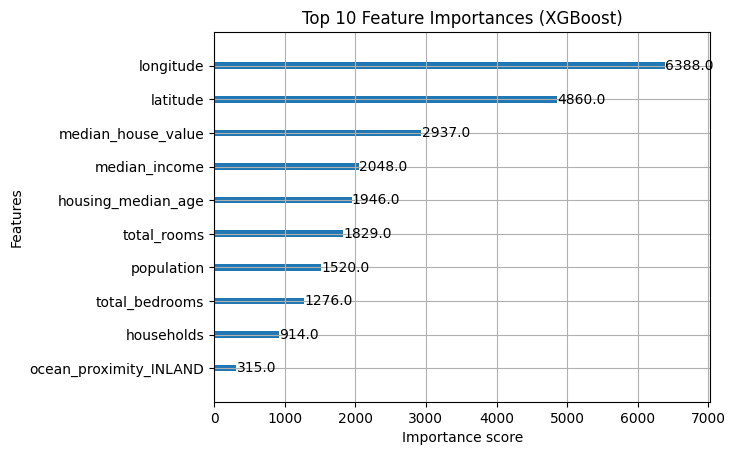

In [16]:
xgb.plot_importance(model, max_num_features=10)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()